# BUILDING A SOLUTION

## Data Preprocessing

In [1]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img
import numpy as np 
import pandas as pd 
import random
import os

class dataset(keras.utils.Sequence): #kế thừa từ lớp sequence trong module keras.utils 

    def __init__(self, csv_file, batch_size=32, count=None, img_size=None):
        self.batch_size = batch_size
        self.csv_file = csv_file
        self.data = pd.read_csv(csv_file)

        y = self.data.iloc[:,3].values # lọc dữ liệu có góc lái = 0
        pos_zero = np.array(np.where(y == 0)).reshape(-1, 1)
        pos_none_zero = np.array(np.where(y != 0)).reshape(-1, 1)
        np.random.shuffle(pos_zero)
        pos_zero = pos_zero[:750]
        pos_combined = np.vstack((pos_zero,pos_none_zero))
        pos_combined = pos_combined.flatten()

        self.data = self.data.iloc[pos_combined].reset_index(drop=True)

        # các hàm lấy dữ liệu về độ dài của tập dữ liệu, kích thước ảnh
        if count is None:
            self.count = self.data.shape[0]
        else:
            self.count = count
        
        if img_size is None:
            size = load_img(self.data.iloc[0,0]).size 
            self.img_size = (size[1], size[0])
        else:
            self.img_size = img_size

    
    def __len__(self):
        return (self.count) // (self.batch_size)
    
    def get_img_size(self):
        return self.img_size

    def mapping(self, x): # hàm ánh xạ
        return (2.0 * x - 1.0)
    
    def __getitem__(self, idx): # hàm tiền xử lý dữ liệu và trả về các lô dữ liệu training
        i = idx * self.batch_size
        batch_data = self.data.iloc[i: min(i + self.batch_size, len(self.data))]

        
        x = np.zeros((len(batch_data),) + (self.img_size) + (3,), dtype='uint8')
        y = np.zeros((len(batch_data),) + (2,))

        for i in range(len(batch_data)):
            img_path = batch_data.iloc[i,0]
            if os.path.exists(img_path):
                imgc = load_img(img_path, target_size=self.img_size)
                imgc = np.array(imgc)
                steering_angle = batch_data.iloc[i,3]
                steering_angle = steering_angle * 1.70 if steering_angle < 0 else steering_angle * 1.85 # tăng độ nhạy cho góc lái
                throttle = self.mapping(batch_data.iloc[i,4]) * 0.1


                if steering_angle != 0: # lật ảnh
                    if random.random() > 0.5:
                        imgc = np.fliplr(imgc)
                        steering_angle = - steering_angle
                
                    if random.random() > 0.5: # tăng sáng tối
                        imgc = np.array(imgc) * random.uniform(0.5, 1.5)
                        imgc = np.clip(imgc, 0, 255)

                x[i] = imgc
                y[i,0] = steering_angle
                y[i,1] = throttle

        return x, y


## Building the Model

In [2]:
from tensorflow.keras import layers

def create_model(inputShape):
    model = keras.models.Sequential([
        layers.Rescaling(1.0 / 255.0, input_shape=inputShape+(3,)),
        layers.Conv2D(24, (5,5), strides=2, padding='same', kernel_initializer='he_normal', activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),
        layers.Conv2D(36, (5,5), strides=2, padding='same', kernel_initializer='he_normal', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(48, (5,5), strides=2, padding='same', kernel_initializer='he_normal', activation='relu'),
        layers.Conv2D(64, (3,3), strides=1, padding='same', kernel_initializer='he_normal', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(78, (3,3), strides=1, padding='same', kernel_initializer='he_normal', activation='relu'),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(200, activation='relu', kernel_initializer='he_normal'),
        layers.Dropout(0.1),
        layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(20, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(2, activation='tanh', kernel_initializer='glorot_uniform')
    ])
    return model 
    

## Training the Model

In [ ]:
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

batch_size = 32
epochs = 30

train_csv_file_path = 'data\data0\driving_log.csv' # đọc file csv cho tập train
val_csv_file_path = 'driving_log.csv' # đọc file csv cho tập val

train_dataset = dataset(train_csv_file_path, batch_size) # gọi lớp dataset để lấy lô dữ liệu được xử lý
if val_csv_file_path is not None:
    val_dataset = dataset(val_csv_file_path, batch_size)
else:
    val_dataset = None

img_shape = train_dataset.get_img_size()

model = create_model(inputShape=img_shape) # tạo mô hình
model.summary()
model.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy']) 

checkpoint = ModelCheckpoint( # lưu mô hình
    os.path.join('models', 'save_at{epoch}.keras'),
    save_best_only=True,
    save_weights_only=False,
    verbose=0,
    monitor='val_loss',
    mode='min'
)

early_stopping = EarlyStopping( # dừng sớm nếu không hiệu quả
    patience=10,
    min_delta=0.0,
    monitor='val_loss',
    mode='min',
    verbose=1
)

reduce_lr = ReduceLROnPlateau( # giảm lr nếu không hiệu quả
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.000001,
    verbose=0,
    mode='min'
)

result = model.fit( # huấn luyện mô hình
    train_dataset, validation_data=val_dataset, epochs=epochs, batch_size=batch_size,
    callbacks=[checkpoint, early_stopping, reduce_lr], verbose = 1
)



<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\doit1\AppData\Local\Temp\ipykernel_22912\166885893.py:7: SyntaxWarning: invalid escape sequence '\d'
  train_csv_file_path = 'data\data0\driving_log.csv'
c:\Users\doit1\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 160, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 80, 160, 24)    │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 160, 24)    │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 160, 24)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 80, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 80, 36)     │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 40, 48)     │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 40, 64)     │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 40, 78)     │        45,006 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 40, 78)     │           312 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │    12,480,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │         2,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,642,596 (48.23 MB)

 Trainable params: 12,642,192 (48.23 MB)

 Non-trainable params: 404 (1.58 KB)

c:\Users\doit1\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 107s 925ms/step - accuracy: 0.5804 - loss: 0.3041 - val_accuracy: 0.4887 - val_loss: 0.0960 - learning_rate: 1.0000e-04
Epoch 2/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 90s 849ms/step - accuracy: 0.6865 - loss: 0.1274 - val_accuracy: 0.6514 - val_loss: 0.0925 - learning_rate: 1.0000e-04
Epoch 3/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 91s 854ms/step - accuracy: 0.7098 - loss: 0.0766 - val_accuracy: 0.7095 - val_loss: 0.0703 - learning_rate: 1.0000e-04
Epoch 4/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 92s 868ms/step - accuracy: 0.7324 - loss: 0.0632 - val_accuracy: 0.7260 - val_loss: 0.0616 - learning_rate: 1.0000e-04
Epoch 5/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 90s 852ms/step - accuracy: 0.7769 - loss: 0.0551 - val_accuracy: 0.7198 - val_loss: 0.0590 - learning_rate: 1.0000e-04
Epoch 6/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 90s 850ms/step - accuracy: 0.8057 - loss: 0.0476 - val_accuracy: 0.7174 - val_loss: 0.0571 - learning_rate: 1.0000e-04
Epoch 7/30
106/106 ━━━━━━━━━━━━━━━━━━━━ 91s 8

## Accuracy Graph

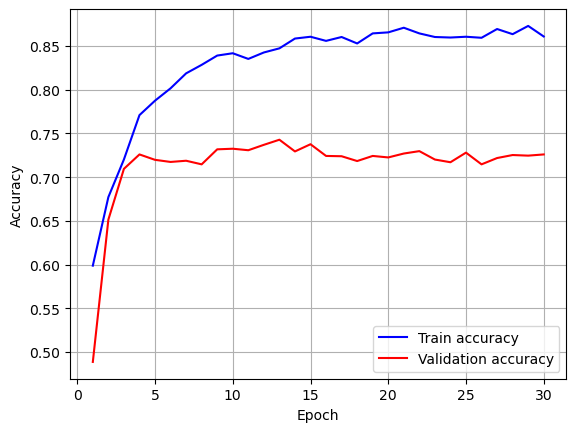

In [8]:
import matplotlib.pyplot as plt
numOFepoch = 30
fig = plt.figure()
plt.plot(np.arange(1, numOFepoch + 1), result.history['accuracy'], label='Train accuracy', color='blue')
plt.plot(np.arange(1, numOFepoch+ 1), result.history['val_accuracy'], label='Validation accuracy', color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Loss Graph

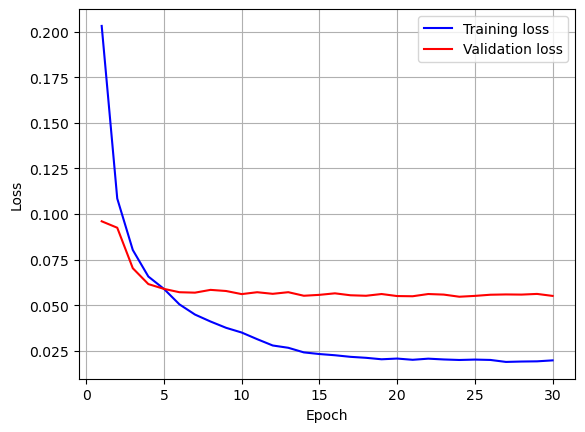

In [ ]:
fig = plt.figure()
plt.plot(np.arange(1, numOFepoch + 1), result.history['loss'], label='Training loss', color='blue')
plt.plot(np.arange(1, numOFepoch+ 1), result.history['val_loss'], label='Validation loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show() 